# Lab 0c — Climate of New York City

<a class="btn btn-primary btn-sm" href="https://dhruvbalwada.github.io/intro-climate-modeling-fall2026/labs/lab0c_nyc_climate.ipynb" download>&#8681; Download this notebook (.ipynb)</a>

*Then upload it to [leap.2i2c.cloud](https://leap.2i2c.cloud/) and open it there.*

*Week 1, in class · Introduction to Climate Modeling*

Daily temperature in Central Park, 1995–2014. We'll use it to answer, concretely: **what is climate?** and **what is a model?** — and to build your *first* climate model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# data lives next to this notebook on the course website;
# use a local copy if you have one, otherwise fetch over the web
base = "data/" if Path("data").is_dir() else "https://dhruvbalwada.github.io/intro-climate-modeling-fall2026/labs/data/"

# 1. station thermometer (NOAA) + 2. ERA5 reanalysis — same file
df = pd.read_csv(base + "centralpark_obs_era5_1995-2014.csv", index_col=0, parse_dates=True)

# 3. a CMIP6 climate model at the same location
cm = pd.read_csv(base + "centralpark_cmip6_MPI-ESM1-2-HR_1995-2014.csv", index_col=0, parse_dates=True)
cm.index = cm.index.normalize()      # model timestamps sit at 12:00; align them to dates
df["t_cmip6"] = cm["t_cmip6"].reindex(df.index)

# 4. eight CMIP6 models at the same location
models = pd.read_csv(base + "centralpark_cmip6_multimodel_1995-2014.csv",
                     index_col=0, parse_dates=True)

df.head()

,t_obs,t_era5,t_cmip6
DATE,,,
1995-01-01,7.50,5.1,-3.799713
1995-01-02,2.25,2.2,-7.446625
1995-01-03,-2.50,-2.2,-7.653137
1995-01-04,-2.75,-2.1,-5.104645
1995-01-05,-6.10,-6.4,-4.841217


## Where this data comes from

Good practice: always know your data's provenance. All three series cover 1995–2014 (the last 20 years of the CMIP6 historical experiment, so they overlap).

| column | source |
|---|---|
| `t_obs` | NOAA NCEI **GHCN-Daily**, station `USW00094728` (NY City Central Park). Daily mean taken as (TMAX+TMIN)/2, the standard convention for long station records. |
| `t_era5` | **ERA5** reanalysis, daily mean 2 m temperature (Copernicus/ECMWF), via the Open-Meteo archive API, nearest grid point to Central Park. |
| `models` | Eight **CMIP6** models (`historical`, `r1i1p1f1`, daily `tas`), same nearest-cell extraction, from the Pangeo cloud archive. |
| `t_cmip6` | **CMIP6 MPI-ESM1-2-HR**, `historical`, `r1i1p1f1`, daily `tas`, from the Pangeo cloud archive; nearest grid cell (40.68 °N, 74.06 °W). |

Curious how these were downloaded? It's all in the optional reference notebook, [**Where our data comes from**](getting_the_data.ipynb). We pre-extracted the files so class doesn't depend on live cloud access.

Three columns, three very different things: **`t_obs`** is a real thermometer, **`t_era5`** is a reanalysis, **`t_cmip6`** is a climate model. We'll look at the observations first and bring the other two in at the end.

## 1. Weather vs climate

Plot a few years of data. Then plot the histogram of **all 20 years**.

mean = 13.1 °C   std = 9.4 °C
record low = -13.3 °C   record high = 34.5 °C


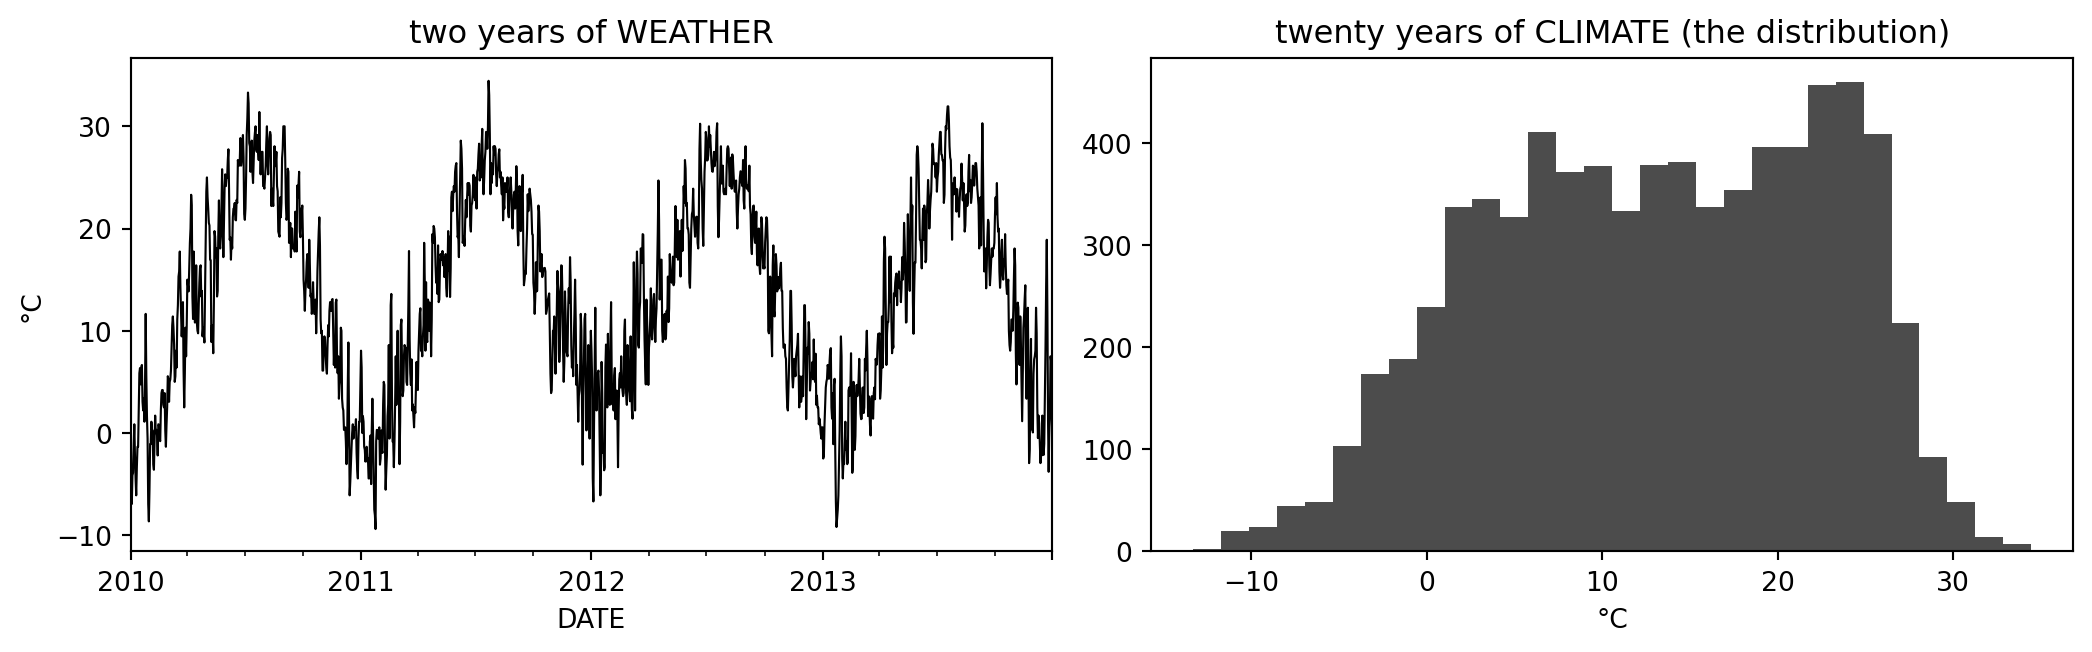

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df["t_obs"]["2010":"2013"].plot(ax=ax[0], lw=0.8, color="k")
ax[0].set_ylabel("°C"); ax[0].set_title("two years of WEATHER")
ax[1].hist(df["t_obs"].dropna(), bins=30, color="k", alpha=0.7)
ax[1].set_xlabel("°C"); ax[1].set_title("twenty years of CLIMATE (the distribution)")
plt.tight_layout()

print(f"mean = {df['t_obs'].mean():.1f} °C   std = {df['t_obs'].std():.1f} °C")
print(f"record low = {df['t_obs'].min():.1f} °C   record high = {df['t_obs'].max():.1f} °C")

There are many aspects to the climate: the mean, the spread of the distribution, the seasonal cycle, variability about the seasonal cycle, days in top 5th percentile, etc, etc.  


## 2. Your first climate model — seasonal cycle fit by eye

Most of the wiggle is the **seasonal cycle**. Let's model temperature as:

$$T(d) \,=\, T_0 \,+\, A\,\cos\!\big(2\pi\,(d - d_{peak})/365 days\big)$$

where $d$ = day of year. **Three parameters — and each one means something physical:**

- $T_0$ = ______ (what does it mean? what are its units?)
- $A$ = ______ (what does it mean? units?)
- $d_{peak}$ = ______ (the day the cycle peaks — what sets it?)

**Your job: pick all three by hand.** Run the cell, look at the plot and the error, adjust, repeat. Stop when you think you have a good fit. 

**When you're happy:** note your $T_0$, $A$, $d_{peak}$ and RMSE — we'll collect them.


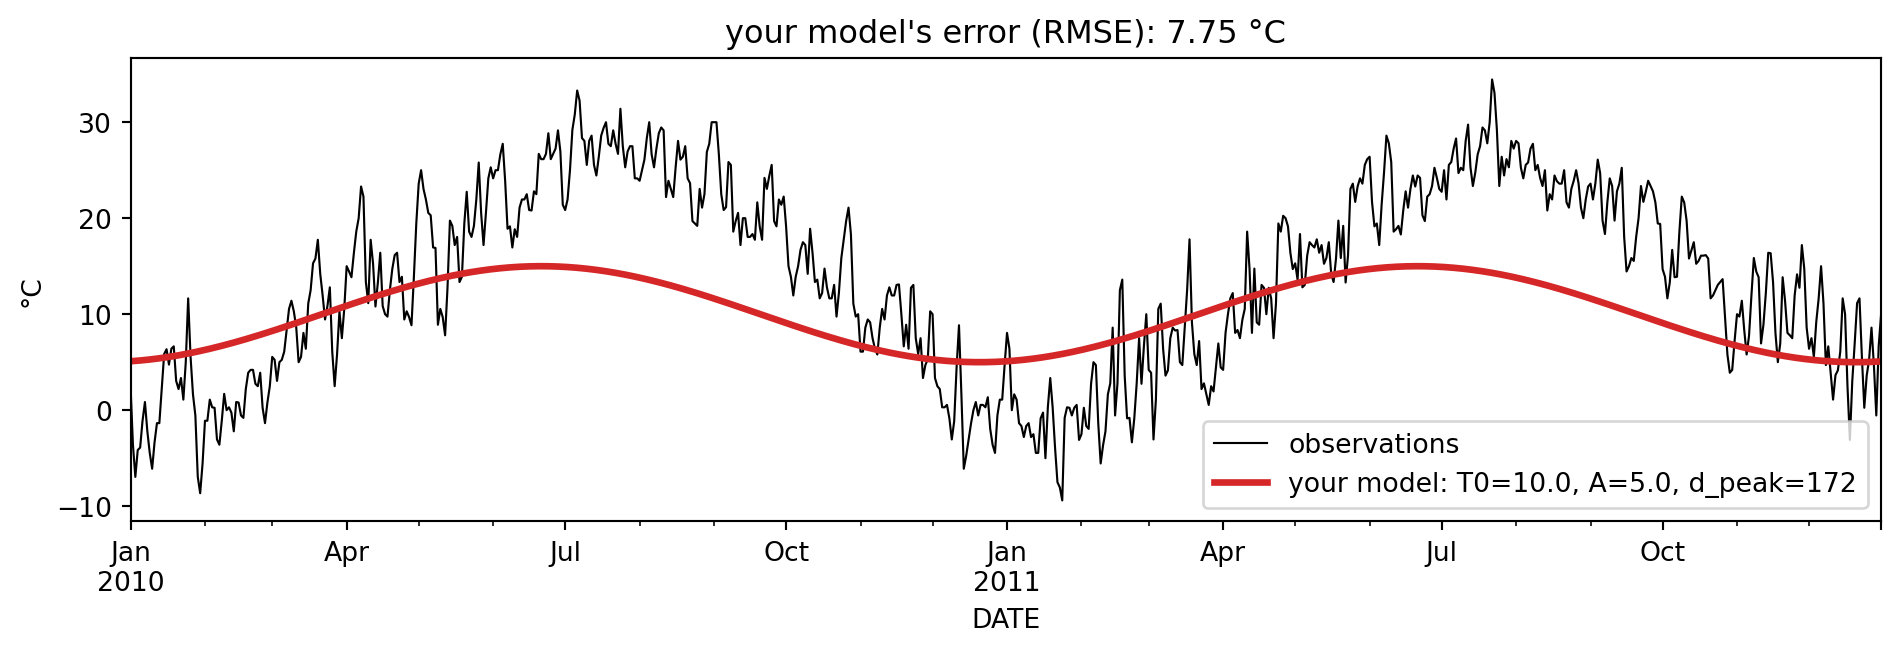

In [3]:
# EDIT THESE THREE NUMBERS, run, look, repeat:
T0    = 10.0    # °C
A     = 5.0     # °C
d_peak = 172    # day of year  (172 = June 21, the summer solstice — is that right?)

doy = df.index.dayofyear
df["t_model"] = T0 + A * np.cos(2 * np.pi * (doy - d_peak) / 365)

fig, ax = plt.subplots(figsize=(10, 3.5))
df["t_obs"]["2010":"2011"].plot(ax=ax, lw=0.8, color="k", label="observations")
df["t_model"]["2010":"2011"].plot(ax=ax, lw=2.5, color="tab:red",
                                  label=f"your model: T0={T0}, A={A}, d_peak={d_peak}")
ax.set_ylabel("°C"); ax.legend()

rmse = np.sqrt(((df["t_obs"] - df["t_model"])**2).mean())
ax.set_title(f"your model's error (RMSE): {rmse:.2f} °C")
plt.tight_layout()


> Everyone fit *the same data* with *the same model* — and got **different numbers**. That spread is **parameter uncertainty**, and you just experienced where it comes from. (A computer can minimize the error too, in some mathematically defined manner.)

**Few things to notice:**

1. Your three-parameter model explains lot of the variance. What physical fact makes the seasonal cycle so predictable, when next Tuesday's weather isn't?
2. Where did your $d_{peak}$ end up? The Sun is strongest at the June solstice (day 172) — but that is almost certainly **not** where you put the peak. Why would the warmest day of the year *lag* the sunniest one? 

## 3. Two more "NYCs": a reanalysis and a climate model

The same location, from **ERA5** (a weather model continuously corrected by observations) and from a **CMIP6 climate model** (free-running — it invents its own weather based on forcing from the sun and the dynamics of different parts of the Earth system).

### 3a. First, the seasonal cycle

Before any statistics: do the three even have the same *climate*? Average every day-of-year over the 20 years.

20-year means:  station 13.1 °C  ·  ERA5 11.5 °C  ·  CMIP6 10.2 °C


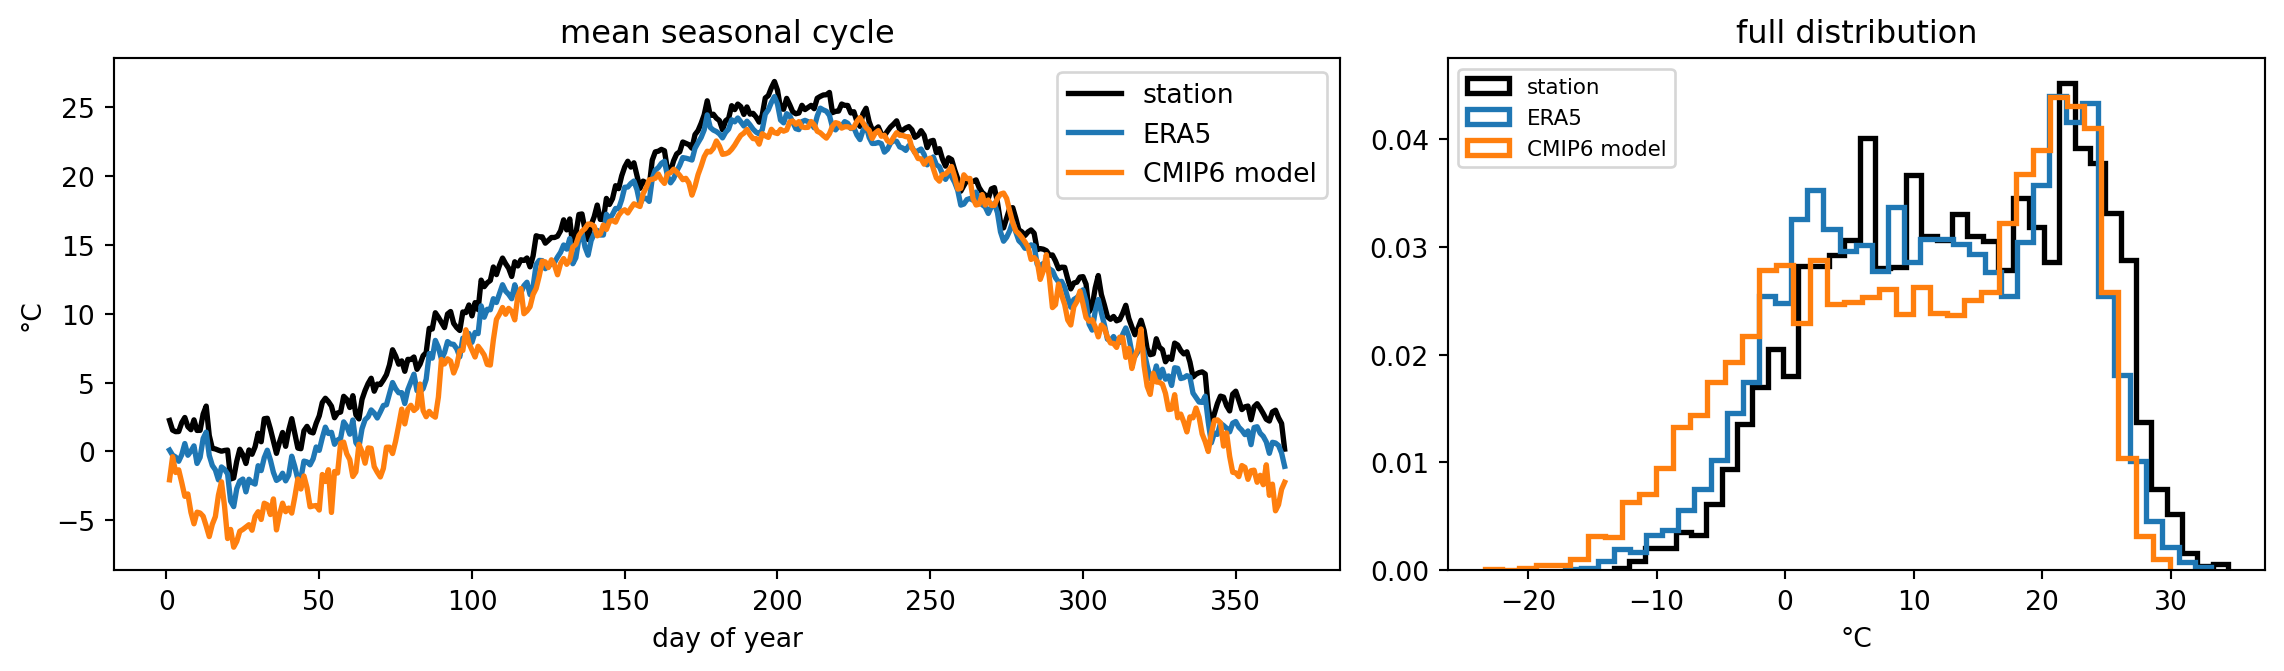

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6), width_ratios=[3, 2])

doyg = df.index.dayofyear
for c, col, lab in [("t_obs", "k", "station"), ("t_era5", "tab:blue", "ERA5"),
                    ("t_cmip6", "tab:orange", "CMIP6 model")]:
    ax[0].plot(df[c].groupby(doyg).mean(), color=col, lw=2, label=lab)
ax[0].set_xlabel("day of year"); ax[0].set_ylabel("°C")
ax[0].set_title("mean seasonal cycle"); ax[0].legend()

for c, col, lab in [("t_obs", "k", "station"), ("t_era5", "tab:blue", "ERA5"),
                    ("t_cmip6", "tab:orange", "CMIP6 model")]:
    ax[1].hist(df[c].dropna(), bins=40, histtype="step", lw=2, color=col, label=lab, density=True)
ax[1].set_xlabel("°C"); ax[1].set_title("full distribution"); ax[1].legend(fontsize=8)
plt.tight_layout()

print("20-year means:  " + "  ·  ".join(
    f"{lab} {df[c].mean():.1f} °C" for c, lab in
    [("t_obs","station"), ("t_era5","ERA5"), ("t_cmip6","CMIP6")]))

All three have a seasonal cycle of roughly the right shape and size — the climate model gets *the climate* broadly right, if a few degrees cold.

### 3b. Now, the weather

Same three series, but zoomed in to individual days.

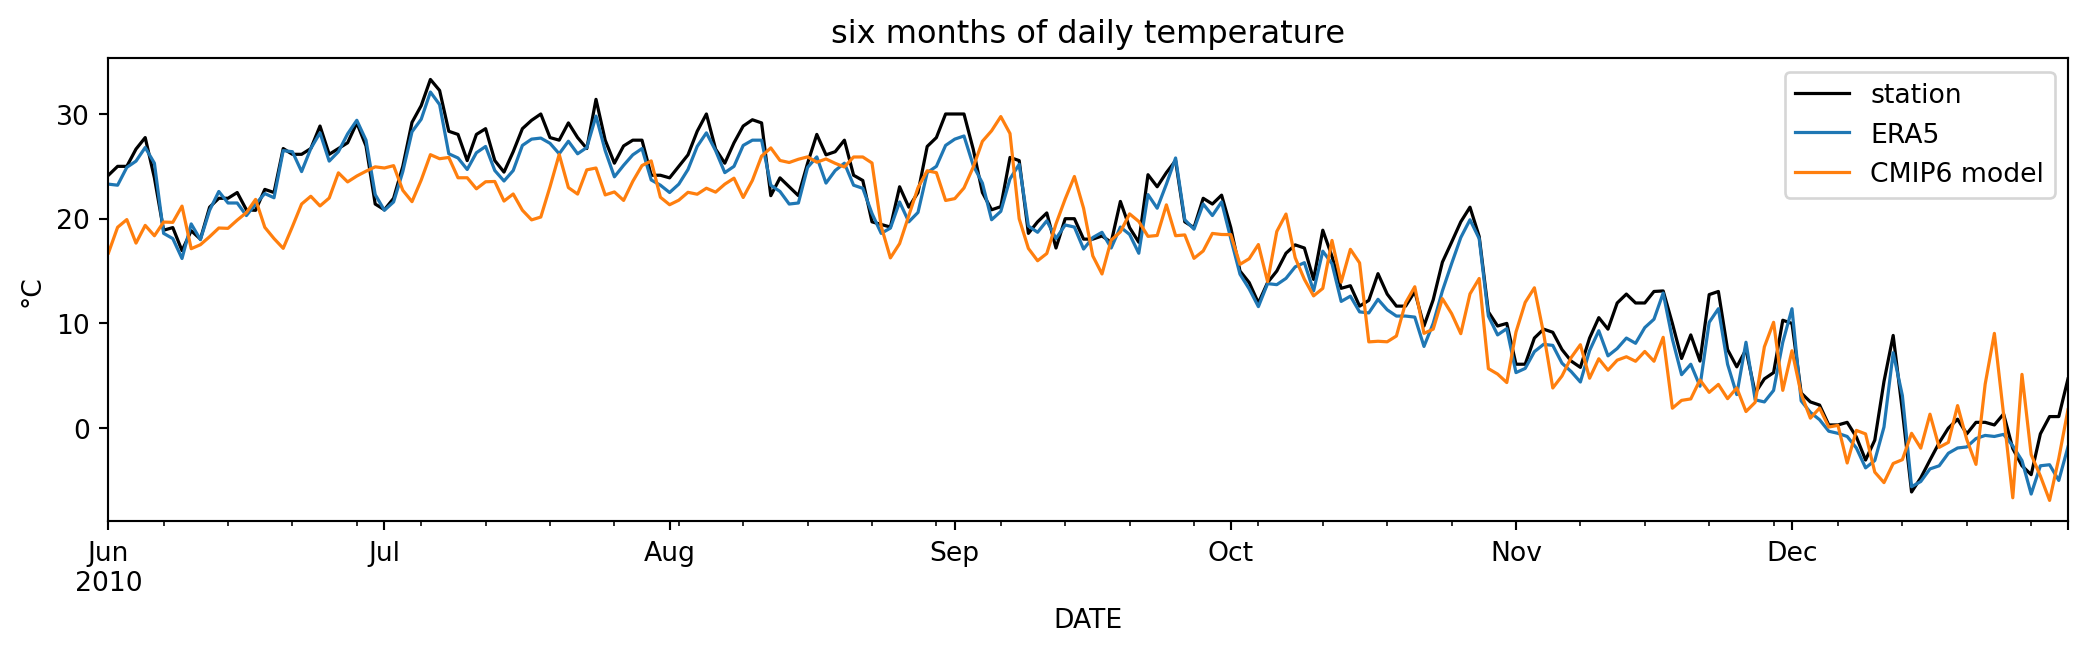

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.5))
for c, col, lab in [("t_obs", "k", "station"), ("t_era5", "tab:blue", "ERA5"), ("t_cmip6", "tab:orange", "CMIP6 model")]:
    df[c]["2010-06":"2010-12"].plot(ax=ax, lw=1.2, color=col, label=lab)
ax.set_ylabel("°C"); ax.legend(); ax.set_title("six months of daily temperature")
plt.tight_layout()

ERA5 rides along with the station; the CMIP6 model does its own thing entirely.

To measure that, we compare **anomalies** — each series with *its own* seasonal cycle subtracted, so what's left is only the weather. (Without this step the correlation would mostly measure "do they both have summers?", which tells us nothing interesting.)

day-to-day correlation with the station, seasonal cycles removed:
  ERA5  : r = 0.95
  CMIP6 : r = -0.01


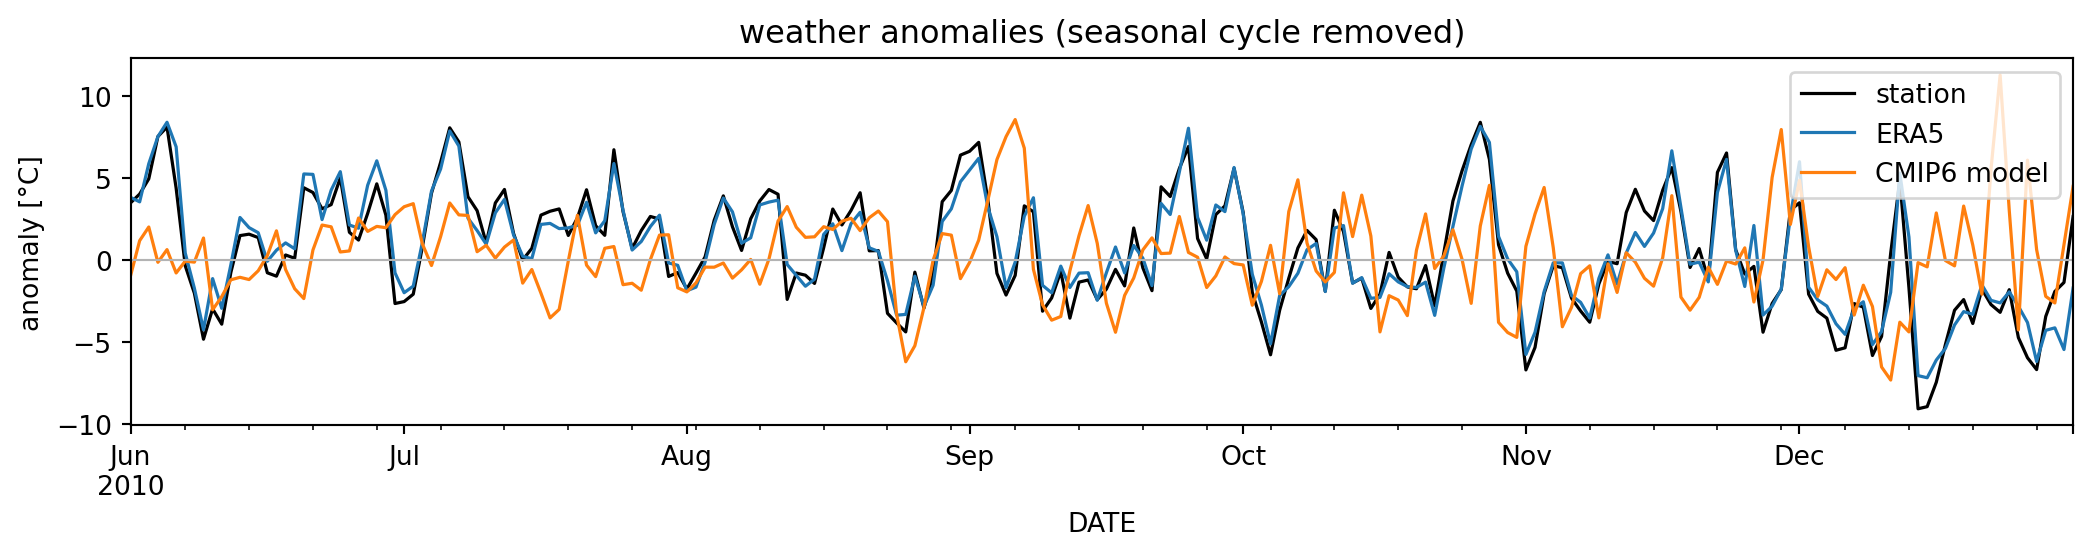

In [6]:
# each series minus its own seasonal cycle -> weather anomalies
anom = df.apply(lambda c: c - c.groupby(doyg).transform("mean"))

fig, ax = plt.subplots(figsize=(11, 3))
for c, col, lab in [("t_obs", "k", "station"), ("t_era5", "tab:blue", "ERA5"),
                    ("t_cmip6", "tab:orange", "CMIP6 model")]:
    anom[c]["2010-06":"2010-12"].plot(ax=ax, lw=1.2, color=col, label=lab)
ax.axhline(0, color="0.7", lw=0.8)
ax.set_ylabel("anomaly [°C]"); ax.legend(); ax.set_title("weather anomalies (seasonal cycle removed)")
plt.tight_layout()

print("day-to-day correlation with the station, seasonal cycles removed:")
print(f"  ERA5  : r = {anom['t_obs'].corr(anom['t_era5']):.2f}")
print(f"  CMIP6 : r = {anom['t_obs'].corr(anom['t_cmip6']):.2f}")

**Discuss (the big ones):**

1. ERA5 tracks the station day-by-day; the CMIP6 model completely ignores it. Why is that *not* a failure of the CMIP6 model? What *should* it get right — and did it, in 3a?
2. All three 20-year means differ (station warmest, CMIP6 coldest). Give two *different kinds* of reasons why. *(One is about what a grid cell is; one is about the model being imperfect.)*
3. Your three-parameter model has a lower RMSE at this station than the CMIP6 model. Is yours the better model? For what, and for what not?

## 4. One model is not the story

You just compared the observations to **one** climate model. But there are dozens, built by different groups, with different grids and different choices inside. Here are eight of them at this same location.

model spread: 9.5 to 15.5 °C   (multi-model mean 11.6 °C)
station 13.1 °C · ERA5 11.5 °C


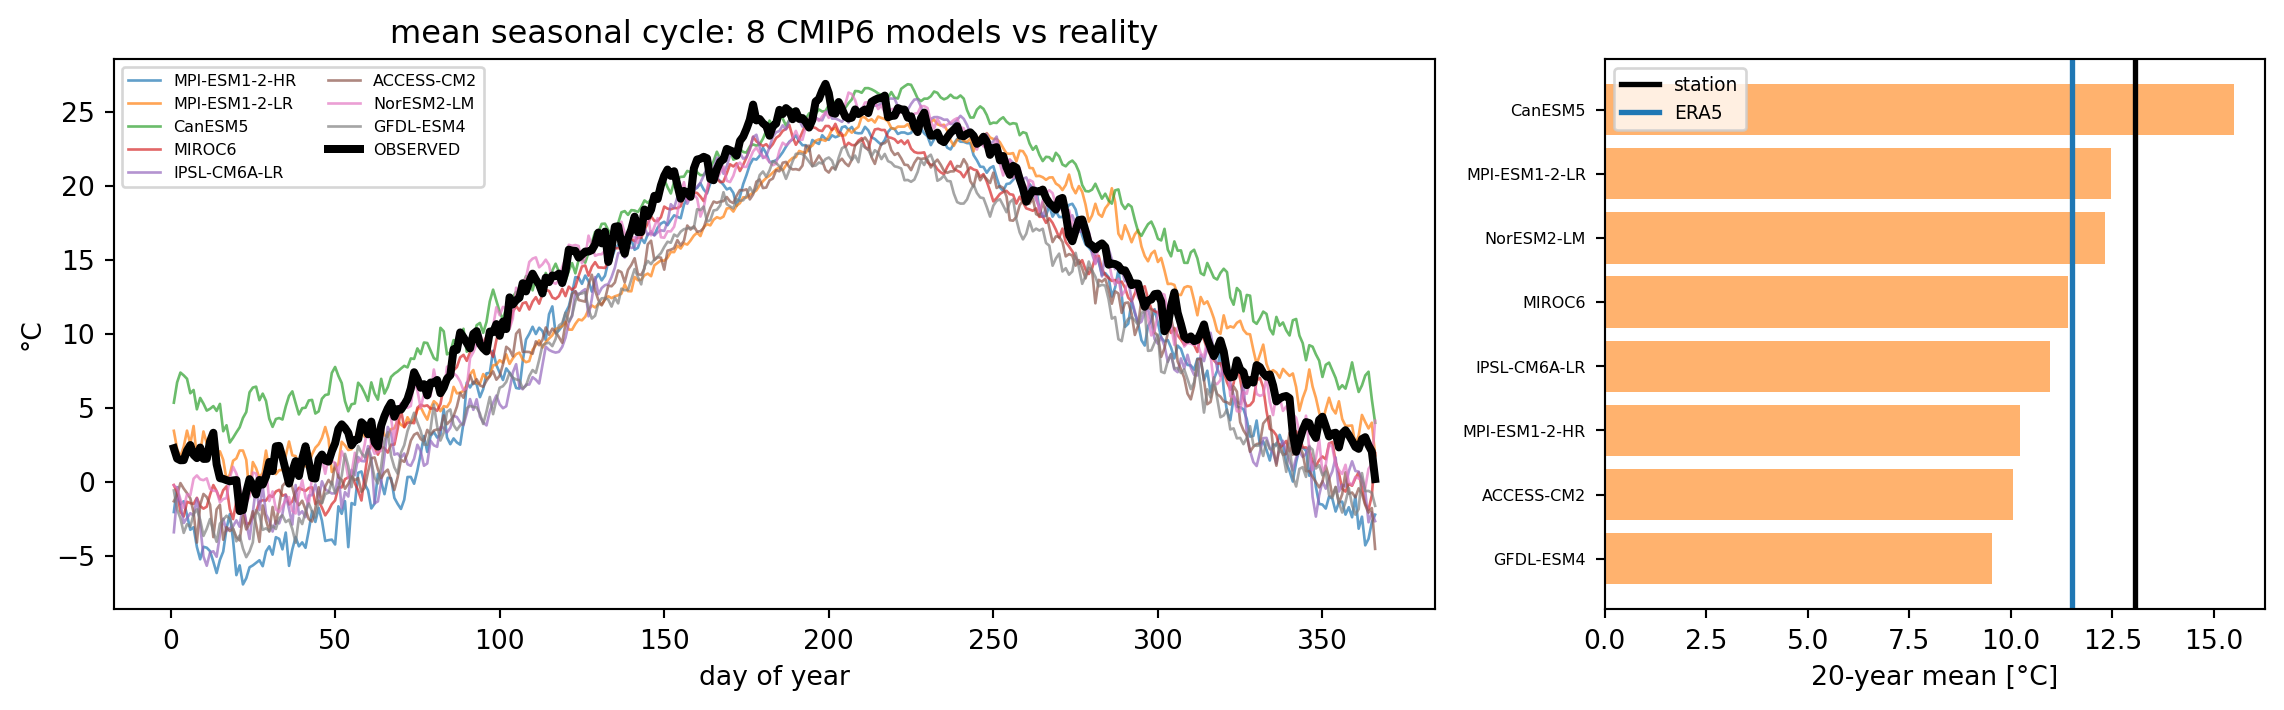

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), width_ratios=[2, 1])

# mean seasonal cycle: every model, plus observations
for m in models.columns:
    ax[0].plot(models[m].groupby(models.index.dayofyear).mean(), lw=1, alpha=0.7, label=m)
ax[0].plot(df["t_obs"].groupby(df.index.dayofyear).mean(), lw=3, color="k", label="OBSERVED")
ax[0].set_xlabel("day of year"); ax[0].set_ylabel("°C")
ax[0].set_title("mean seasonal cycle: 8 CMIP6 models vs reality")
ax[0].legend(fontsize=6, ncol=2)

# 20-year mean temperature: where does reality sit?
means = models.mean().sort_values()
ax[1].barh(range(len(means)), means.values, color="tab:orange", alpha=0.6)
ax[1].set_yticks(range(len(means))); ax[1].set_yticklabels(means.index, fontsize=6)
ax[1].axvline(df["t_obs"].mean(), color="k", lw=2, label="station")
ax[1].axvline(df["t_era5"].mean(), color="tab:blue", lw=2, label="ERA5")
ax[1].set_xlabel("20-year mean [°C]"); ax[1].legend(fontsize=7)
plt.tight_layout()

print(f"model spread: {means.min():.1f} to {means.max():.1f} °C   (multi-model mean {means.mean():.1f} °C)")
print(f"station {df['t_obs'].mean():.1f} °C · ERA5 {df['t_era5'].mean():.1f} °C")

**Discuss:**

1. Earlier, one model looked ~3 °C too cold and you might have concluded it was simply wrong. Where do the observations sit relative to the *whole* set of models?
2. This spread — models disagreeing with each other — is called **model uncertainty**. What would you report to someone who asks "what is the climate of New York?" using this ensemble?
3. The warmest model has the coarsest grid, and its nearest cell to Central Park sits over the **ocean**. Does that make it a bad model, or a model being asked the wrong question?